# Does a higher level of education lead to a more democratic society ?

Author: Ayşegül Ada Benhür 

Date: January 2026


## 1 - Library import

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import statsmodels.formula.api as smf 
import networkx as nx 
import scipy.stats.distributions

## 2 - Directed Acyclic Graph

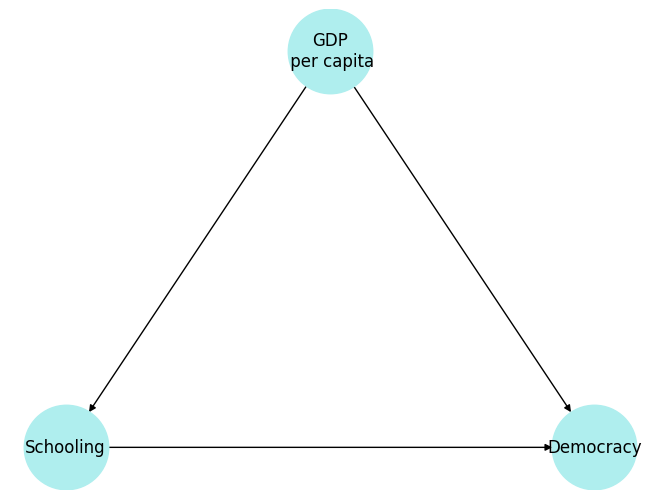

In [2]:
G = nx.DiGraph()

nodes = ['Schooling', 'Democracy', 'GDP\n per capita']
G.add_nodes_from(nodes)

edges = [('GDP\n per capita', 'Schooling'), ('Schooling', 'Democracy'), ('GDP\n per capita', 'Democracy')]
G.add_edges_from(edges)

pos = nx.planar_layout(G)
nx.draw(G, pos, with_labels = True, node_size = 3700, node_color ='paleturquoise', arrows = True)
plt.show()

    Predictions:

- Higher years of schooling lead to a higher democracy score.

- Higher GDP per capita is associated with a higher democracy score.


## 3 - Data import

In [3]:
df_gdp = pd.read_csv("gdp-per-capita-maddison-project-database.csv")
df_schooling = pd.read_csv("mean-years-of-schooling-long-run.csv")
df_regime = pd.read_csv("political-regime.csv")

display(df_gdp, df_schooling, df_regime)


,Entity,Code,Year,GDP per capita,900793-annotations
0,Afghanistan,AFG,1950,1156.0000,NaN
1,Afghanistan,AFG,1951,1170.0000,NaN
2,Afghanistan,AFG,1952,1189.0000,NaN
3,Afghanistan,AFG,1953,1240.0000,NaN
4,Afghanistan,AFG,1954,1245.0000,NaN
...,...,...,...,...,...
21581,Zimbabwe,ZWE,2018,1900.1992,NaN
21582,Zimbabwe,ZWE,2019,1753.0244,NaN
21583,Zimbabwe,ZWE,2020,1585.9728,NaN
21584,Zimbabwe,ZWE,2021,1687.2532,NaN


,Entity,Code,Year,Combined - average years of education for 15-64 years male and female youth and adults
0,Afghanistan,AFG,1870,0.01
1,Afghanistan,AFG,1875,0.01
2,Afghanistan,AFG,1880,0.01
3,Afghanistan,AFG,1885,0.01
4,Afghanistan,AFG,1890,0.01
...,...,...,...,...
4306,Zimbabwe,ZWE,2020,8.32
4307,Zimbabwe,ZWE,2025,8.55
4308,Zimbabwe,ZWE,2030,8.82
4309,Zimbabwe,ZWE,2035,9.08


,Entity,Code,Year,Political regime
0,Afghanistan,AFG,1789,0
1,Afghanistan,AFG,1790,0
2,Afghanistan,AFG,1791,0
3,Afghanistan,AFG,1792,0
4,Afghanistan,AFG,1793,0
...,...,...,...,...
31303,Zimbabwe,ZWE,2020,1
31304,Zimbabwe,ZWE,2021,1
31305,Zimbabwe,ZWE,2022,1
31306,Zimbabwe,ZWE,2023,1


## 4 - Data manipulation

In [4]:

df_schooling = df_schooling.rename(columns={'Combined - average years of education for 15-64 years male and female youth and adults': 'Schooling'})
df_regime = df_regime.rename(columns={'Political regime': 'Democracy_Score'})

# The GDP file has an 'annotations' column that is mostly empty. 
if '900793-annotations' in df_gdp.columns:
    df_gdp = df_gdp.drop(columns=['900793-annotations'])

df_merged = pd.merge(df_gdp, df_schooling, on=['Entity', 'Code', 'Year'], how='inner')
df_merged = pd.merge(df_merged, df_regime, on=['Entity', 'Code', 'Year'], how='inner')

df_final = df_merged[df_merged['Year'] == 2020].copy().dropna()
df_final.to_csv("merged_democracy_data.csv", index=False)


In [5]:
# We map 0 & 1 to 0 (Autocracy) and scores 2 & 3 to 1 (Democracy)
df_final['Democracy'] = df_final['Democracy_Score'].apply(lambda x: 1 if x >= 2 else 0)

In [6]:
df_final['log_gdp_per_capita'] = np.log10(df_final['GDP per capita'])

In [7]:
df_final

,Entity,Code,Year,GDP per capita,Schooling,Democracy_Score,Democracy,log_gdp_per_capita
14,Afghanistan,AFG,2020,1928.4547,5.69,1,0,3.285209
29,Albania,ALB,2020,11372.5410,10.32,2,1,4.055858
43,Algeria,DZA,2020,13086.2930,8.18,1,0,4.116817
74,Argentina,ARG,2020,15975.8390,9.86,2,1,4.203464
76,Armenia,ARM,2020,11546.1760,10.54,2,1,4.062438
...,...,...,...,...,...,...,...,...
2300,Venezuela,VEN,2020,4952.5300,9.33,1,0,3.694827
2302,Vietnam,VNM,2020,7395.3613,8.35,1,0,3.868959
2308,Yemen,YEM,2020,2031.4436,5.56,0,0,3.307805
2329,Zambia,ZMB,2020,3270.5990,8.37,1,0,3.514627


## 5 - Data description

In [8]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': 'Times New Roman',
    
})

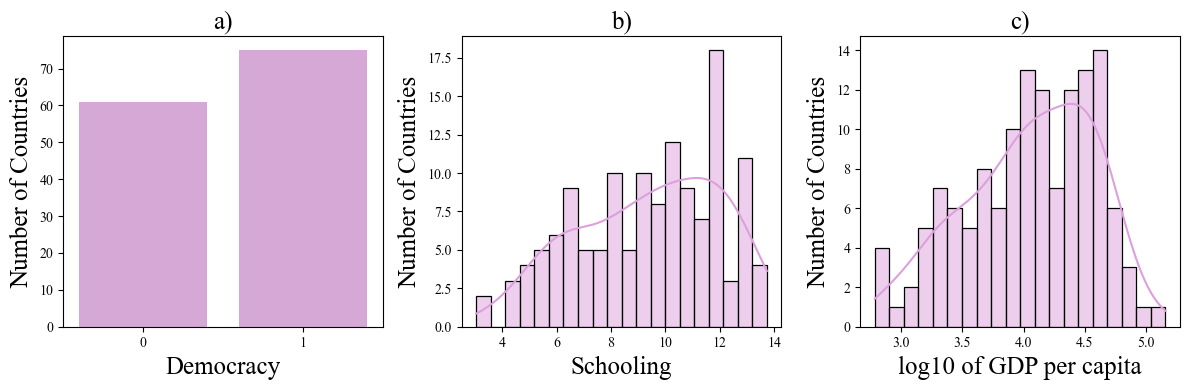

In [9]:

fig1 = plt.figure(figsize = (12, 4))

# Figure 1.a : Democracy  
plt.subplot(1, 3, 1) 
sns.countplot(x='Democracy', data=df_final, color='plum')
plt.gca().set_xlabel("Democracy", size = 18)
plt.gca().set_ylabel("Number of Countries", size = 18)
plt.title("a)", size = 18)

# Figure 1.b : Schooling 
plt.subplot(1, 3, 2) 
sns.histplot(df_final['Schooling'], bins=20, kde=True, color='plum')
plt.gca().set_xlabel("Schooling", size = 18)
plt.gca().set_ylabel("Number of Countries", size = 18)
plt.title("b)", size = 18)

# Figure 1.c : Distribution of GDP per capita
plt.subplot(1, 3, 3) 
sns.histplot(df_final['log_gdp_per_capita'], bins=20, kde=True, color='plum')
plt.gca().set_xlabel("log10 of GDP per capita", size = 18)
plt.gca().set_ylabel("Number of Countries", size = 18)
plt.title("c)", size = 18)
plt.tight_layout()


plt.show()

## 6. Data modelling

### 6.1. - Multivariate logistic regression

We computed the following logistic regression model:

$P(Democracy_{i}​=1∣X_{i}​) = sig(\beta_{0} + \beta_{1} GDPpc_{i} + \beta_{2} Schooling_{i})$

In [10]:
# Normalize Schooling (0 to 1)
min_s = df_final['Schooling'].min()
max_s = df_final['Schooling'].max()
df_final['Schooling_Norm'] = (df_final['Schooling'] - min_s) / (max_s - min_s)

# Normalize log GDP (0 to 1)
min_g = df_final['log_gdp_per_capita'].min()
max_g = df_final['log_gdp_per_capita'].max()
df_final['GDP_Norm'] = (df_final['log_gdp_per_capita'] - min_g) / (max_g - min_g)


print(df_final[['Schooling_Norm', 'GDP_Norm', 'Democracy']].describe())

       Schooling_Norm    GDP_Norm   Democracy
count      136.000000  136.000000  136.000000
mean         0.593162    0.532332    0.551471
std          0.243857    0.220907    0.499182
min          0.000000    0.000000    0.000000
25%          0.401402    0.375868    0.000000
50%          0.625701    0.555439    1.000000
75%          0.802804    0.705867    1.000000
max          1.000000    1.000000    1.000000


In [11]:
model = smf.logit(formula = 'Democracy ~ Schooling_Norm + GDP_Norm', data = df_final).fit(method='bfgs')
model.summary()

Optimization terminated successfully.
         Current function value: 0.571745
         Iterations: 25
         Function evaluations: 26
         Gradient evaluations: 26


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              Democracy   No. Observations:                  136
Model:                          Logit   Df Residuals:                      133
Method:                           MLE   Df Model:                            2
Date:                Wed, 28 Jan 2026   Pseudo R-squ.:                  0.1688
Time:                        20:32:10   Log-Likelihood:                -77.757
converged:                       True   LL-Null:                       -93.546
Covariance Type:            nonrobust   LLR p-value:                 1.390e-07
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -2.4611      0.588     -4.188      0.000      -3.613      -1.309
Schooling_Norm     4.3441      1.424      3.050      0.002       1.553       7.135
GDP_Norm           0.2235      1.497      0.149      0.881      -2.711       3.158
==================================================================================
"""

### 6.2. Forest plot

In [12]:
# Column standardization
df_scale = df_final

df_scale.loc[:, 'log_gdp_per_capita'] = df_scale['log_gdp_per_capita'] / df_scale['log_gdp_per_capita'].std()
df_scale.loc[:, 'log_gdp_per_capita'] = df_scale['log_gdp_per_capita'] - df_scale['log_gdp_per_capita'].mean()

We computed the following logistic regression model:

$P(Democracy_{i}​=1∣X_{i}​) = sig(\beta_{0} + \beta_{1} GDP per capita_{i} + \beta_{2} Schooling_{i})$

In [13]:
model = smf.logit(formula = 'Democracy ~ log_gdp_per_capita + Schooling', data = df_scale).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.571745
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              Democracy   No. Observations:                  136
Model:                          Logit   Df Residuals:                      133
Method:                           MLE   Df Model:                            2
Date:                Wed, 28 Jan 2026   Pseudo R-squ.:                  0.1688
Time:                        20:32:10   Log-Likelihood:                -77.757
converged:                       True   LL-Null:                       -93.546
Covariance Type:            nonrobust   LLR p-value:                 1.390e-07
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -3.5762      1.256     -2.848      0.004      -6.037      -1.115
log_gdp_per_capita     0.0494      0.331      0.149      0.881      -0.599       0.698
Schooling              0.4060      0.133      3.050      0.002       0.145       0.667
======================================================================================
"""

In [14]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': 'Times New Roman',
    'font.size': 16
})

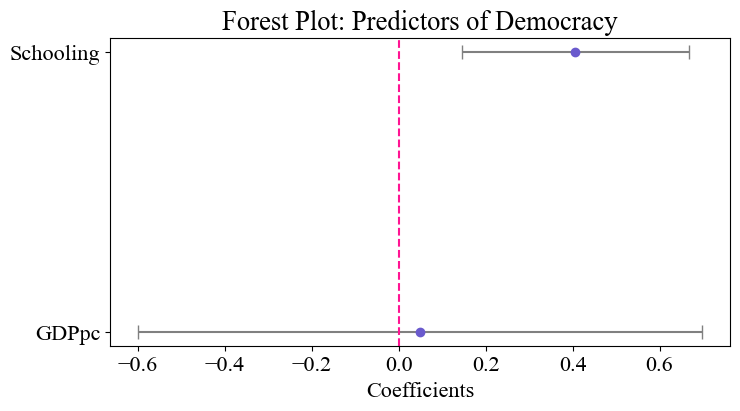

In [15]:
coefs = model.params.drop("Intercept")
conf_int = model.conf_int().drop("Intercept")
errors = conf_int[1] - coefs  

plt.figure(figsize=(8, 4))
plt.errorbar(coefs, ['GDPpc', 'Schooling'], xerr=errors, fmt='o', color='slateblue', ecolor='gray', capsize=5)
plt.axvline(x=0, color='deeppink', linestyle='--')
plt.title("Forest Plot: Predictors of Democracy")
plt.xlabel("Coefficients")
plt.show()